In [1]:
import pandas as pd

url = "https://github.com/digital-wellbeing/open-play/raw/v1.2.6/data/clean/survey_biweekly.csv.gz"
survey = pd.read_csv(url, low_memory=False)

# The columns we need: weekly playtime, loss of control (gdt), depression (promis)
cols = ["pid", "self_reported_weekly_play",
        "gdt_1", "gdt_2", "gdt_3", "gdt_4",
        "promis_1", "promis_2", "promis_3", "promis_4",
        "promis_5", "promis_6", "promis_7", "promis_8"]
survey[cols].head()

,pid,self_reported_weekly_play,gdt_1,gdt_2,gdt_3,gdt_4,promis_1,promis_2,promis_3,promis_4,promis_5,promis_6,promis_7,promis_8
0,p100362329,1800.0,Sometimes,Sometimes,Rarely,Rarely,1.0,1.0,2.0,3.0,2.0,3.0,3.0,1.0
1,p1009647790,1200.0,Sometimes,Sometimes,Sometimes,Rarely,4.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0
2,p1009647790,1500.0,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
3,p1009647790,1800.0,NaN,NaN,NaN,NaN,4.0,3.0,3.0,3.0,4.0,2.0,3.0,2.0
4,p1009647790,1500.0,NaN,NaN,NaN,NaN,2.0,3.0,2.0,3.0,3.0,2.0,3.0,3.0


### Loss of control over gaming (Gaming Disorder Test)

Players answered 4 questions about the **last 3 months**:

| Column | Question |
|---|---|
| `gdt_1` | I have had difficulties controlling my gaming activity. |
| `gdt_2` | I have given increasing priority to gaming over other life interests and daily activities. |
| `gdt_3` | I have continued gaming despite the occurrence of negative consequences. |
| `gdt_4` | I have experienced significant problems in life due to the severity of my gaming behavior. |

The answers are stored as **words**, so we first convert them into **numbers**:

| Answer | Value |
|---|---|
| Never | 1 |
| Rarely | 2 |
| Sometimes | 3 |
| Often | 4 |
| Very often | 5 |

**Score = sum of the 4 answers**, from **4** (never any problem) to **20** (very often all of them).
The higher the score, the more the player loses control over gaming.
The score is only computed when all 4 answers are present.

In [2]:
# Convert the words into numbers
word_to_number = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Very often": 5}
control_items = ["gdt_1", "gdt_2", "gdt_3", "gdt_4"]

for col in control_items:
    survey[col] = survey[col].map(word_to_number)

# Loss-of-control score = sum of the 4 answers (only if all 4 are answered)
survey["loss_of_control"] = survey[control_items].sum(axis=1, min_count=4)

survey["loss_of_control"].describe()

count    2499.000000
mean        8.321729
std         3.309213
min         4.000000
25%         6.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: loss_of_control, dtype: float64

Only about 2,500 surveys have a loss-of-control score: these questions were asked
**only in the 1st and 6th survey** (they cover the last 3 months), so the other surveys
are empty for these columns. This is expected.

In [4]:
# Depression score = sum of the 8 PROMIS answers (only if all 8 are answered)
depression_items = ["promis_1", "promis_2", "promis_3", "promis_4",
                    "promis_5", "promis_6", "promis_7", "promis_8"]
survey["depression"] = survey[depression_items].sum(axis=1, min_count=8)

survey["depression"].describe()

count    6678.000000
mean       18.339024
std         8.190634
min         8.000000
25%        11.000000
50%        17.000000
75%        24.000000
max        40.000000
Name: depression, dtype: float64

### Depressive symptoms (PROMIS Depression, 8 questions)

Players rated 8 statements about the **last 7 days** (e.g. *"I felt worthless"*,
*"I felt sad"*, *"I felt hopeless"*), from **1 = never** to **5 = always**.
**Score = sum of the 8 answers**, from **8** (no symptoms) to **40** (all symptoms, all the time).
The higher the score, the worse the player feels.

The average score is **18.4**, below the middle of the scale (24):
most players report few to moderate symptoms.

In [6]:
# Weekly playtime: from minutes to hours
survey["hours_week"] = survey["self_reported_weekly_play"] / 60

survey["hours_week"].describe()

count    5199.000000
mean       18.172129
std        18.020133
min         0.000000
25%         6.000000
50%        14.000000
75%        25.000000
max       420.000000
Name: hours_week, dtype: float64

In [7]:
# Hours above 100 per week (~14 h a day, every day) are not credible: we remove them
too_high = survey["hours_week"] > 100
print(too_high.sum(), "impossible answers removed")

survey["hours_week"] = survey["hours_week"].where(~too_high)

survey["hours_week"].describe()

18 impossible answers removed


count    5181.000000
mean       17.731217
std        15.826486
min         0.000000
25%         6.000000
50%        14.000000
75%        25.000000
max       100.000000
Name: hours_week, dtype: float64

**Removing impossible values**

Some players reported more than 168 hours of play in a week, which is impossible
(the maximum was 420 h). We consider answers above **100 hours per week**
(about 14 hours a day, every day) as input errors and remove them.
Only the playtime value is removed; the rest of the survey is kept.

In [8]:
# One row per player: average over all their surveys
players = survey.groupby("pid")[["hours_week", "loss_of_control", "depression"]].mean()

# Keep only players with a depression score
players = players.dropna(subset=["depression"])

print(len(players), "players with a depression score")
players.notna().sum()

1831 players with a depression score


hours_week         1573
loss_of_control    1743
depression         1831
dtype: int64

**One row per player**

We average each player's surveys so that every player counts once.
- **1,831 players** have a depression score;
- **1,743** of them also have a loss-of-control score (blue line);
- **1,573** of them also have a valid weekly playtime (grey line).
Each line of the chart uses the players who have the information it needs.

In [9]:
# Players with a loss-of-control score
control = players.dropna(subset=["loss_of_control"]).copy()

# Split them into 4 groups of equal size (quartiles)
labels = ["Lowest 25%", "2nd quarter", "3rd quarter", "Highest 25%"]
control["group"] = pd.qcut(control["loss_of_control"].rank(method="first"), 4, labels=labels)

# Average depression score + margin of error for each group
summary_control = control.groupby("group", observed=True)["depression"].agg(["mean", "count", "sem"])
summary_control["margin"] = 1.96 * summary_control["sem"]
summary_control.round(2)

,mean,count,sem,margin
group,,,,
Lowest 25%,15.91,436,0.37,0.73
2nd quarter,17.52,436,0.35,0.68
3rd quarter,19.07,435,0.33,0.65
Highest 25%,21.68,436,0.36,0.70


**Depression by loss of control**

Players are split into 4 groups of equal size (quartiles) according to their
loss-of-control score. Depressive symptoms rise steadily:
**15.9 → 17.5 → 19.1 → 21.7** (out of 40), almost **6 points** between the quarter
of players who keep control the most and the quarter who lose it the most.

In [11]:
# Players with a valid weekly playtime
hours = players.dropna(subset=["hours_week"]).copy()

# Split them into 4 groups of equal size (quartiles)
hours["group"] = pd.qcut(hours["hours_week"].rank(method="first"), 4, labels=labels)

# Average depression score + margin of error for each group
summary_hours = hours.groupby("group", observed=True)["depression"].agg(["mean", "count", "sem"])
summary_hours["margin"] = 1.96 * summary_hours["sem"]
summary_hours.round(2)

,mean,count,sem,margin
group,,,,
Lowest 25%,18.14,394,0.36,0.71
2nd quarter,17.42,393,0.37,0.73
3rd quarter,18.93,393,0.39,0.76
Highest 25%,19.38,393,0.41,0.80


**Depression by hours played**

Same method, with weekly playtime instead of loss of control:
**18.1 → 17.4 → 18.9 → 19.4**. The difference between the lowest and highest quarter
is only about **1 point**, and the pattern is not regular.
Loss of control is much more strongly linked to depressive symptoms than hours played.

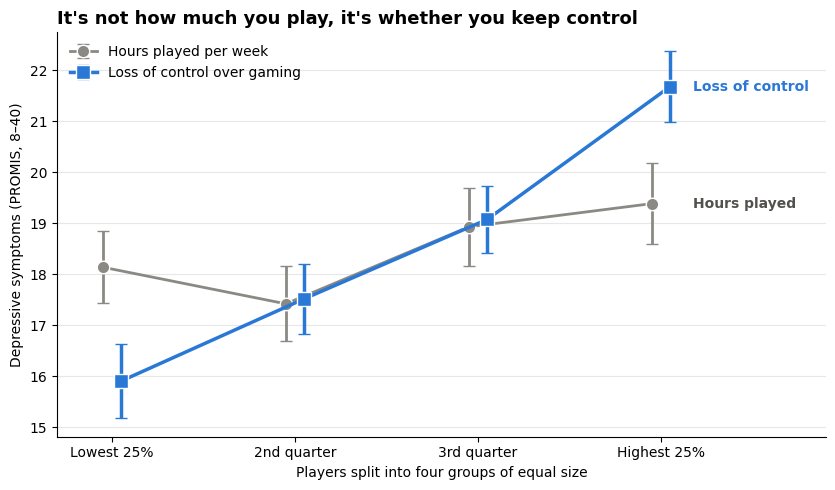

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8.5, 5))

# Grey line: groups by hours played (circles)
ax.errorbar(x - 0.05, summary_hours["mean"], yerr=summary_hours["margin"],
            fmt="o-", color="#8a8984", markersize=9, capsize=4, linewidth=2,
            markeredgecolor="white", label="Hours played per week")

# Blue line: groups by loss of control (squares)
ax.errorbar(x + 0.05, summary_control["mean"], yerr=summary_control["margin"],
            fmt="s-", color="#2a78d6", markersize=10, capsize=4, linewidth=2.5,
            markeredgecolor="white", label="Loss of control over gaming")

# Name each line directly at its end
ax.annotate("Loss of control", (3.1, summary_control["mean"].iloc[-1]), xytext=(10, 0),
            textcoords="offset points", va="center", color="#2a78d6", fontweight="bold")
ax.annotate("Hours played", (3.1, summary_hours["mean"].iloc[-1]), xytext=(10, 0),
            textcoords="offset points", va="center", color="#52514e", fontweight="bold")

# Axes, title, style
ax.set_xticks(x, labels)
ax.set_xlim(-0.3, 3.9)
ax.set_xlabel("Players split into four groups of equal size")
ax.set_ylabel("Depressive symptoms (PROMIS, 8–40)")
ax.set_title("It's not how much you play, it's whether you keep control",
             loc="left", fontweight="bold", fontsize=13)
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool, Whisker
from bokeh.plotting import figure

output_notebook()   # display Bokeh charts inside the notebook

# Put the numbers of one line into a Bokeh "source"
def make_source(summary, shift):
    return ColumnDataSource(dict(
        x=[i + shift for i in range(len(labels))],
        group=labels,
        mean=summary["mean"].round(1),
        low=(summary["mean"] - summary["margin"]).round(1),
        high=(summary["mean"] + summary["margin"]).round(1),
        n=summary["count"],
    ))

src_hours = make_source(summary_hours, -0.05)
src_control = make_source(summary_control, 0.05)

# Vertical range: leave room for the error bars
lowest = min(src_hours.data["low"].min(), src_control.data["low"].min()) - 0.5
highest = max(src_hours.data["high"].max(), src_control.data["high"].max()) + 0.5

p = figure(width=750, height=430, toolbar_location=None, y_range=(lowest, highest),
           title="It's not how much you play, it's whether you keep control")

# Grey line (hours) with circles, blue line (loss of control) with squares
for src, color, marker, name in [(src_hours, "#8a8984", "circle", "Hours played per week"),
                                 (src_control, "#2a78d6", "square", "Loss of control over gaming")]:
    p.line("x", "mean", source=src, color=color, line_width=2.5, legend_label=name)
    whisker = Whisker(source=src, base="x", lower="low", upper="high", line_color=color)
    whisker.upper_head.line_color = color
    whisker.lower_head.line_color = color
    p.add_layout(whisker)
    dots = p.scatter("x", "mean", source=src, marker=marker, size=12, color=color,
                     line_color="white", line_width=2, legend_label=name)
    p.add_tools(HoverTool(renderers=[dots], tooltips=[
        ("Line", name), ("Group", "@group"), ("Mean score", "@mean"),
        ("95% interval", "@low – @high"), ("Players", "@n")]))

# Axis labels: show the group names instead of 0, 1, 2, 3
p.xaxis.ticker = [0, 1, 2, 3]
p.xaxis.major_label_overrides = {i: g for i, g in enumerate(labels)}
p.xaxis.axis_label = "Players split into four groups of equal size"
p.yaxis.axis_label = "Depressive symptoms (PROMIS, 8–40)"
p.legend.location = "top_left"
p.xgrid.grid_line_color = None
p.outline_line_color = None

show(p)

Loading BokehJS ...